# Dengue Surveillance Analysis in Guatemala, 2012–2024


## Executive Summary

This section will be completed after the department-level analysis is finalized.


## 1. Project Overview


### 1.1 Research Question

How did reported dengue cases change across Guatemala between 2012 and 2024, and what temporal and geographic patterns emerge from national surveillance data?

### 1.2 General Objective

Analyze the temporal and geographic distribution of reported dengue cases in Guatemala between 2012 and 2024 using exploratory data analysis and descriptive statistical methods.

### 1.3 Specific Objectives

* Describe annual trends in reported dengue cases between 2012 and 2024.
* Identify municipalities and departments contributing the greatest cumulative dengue burden.
* Evaluate the geographic concentration of reported dengue cases using descriptive statistics and Pareto analysis.
* Identify municipalities that consistently ranked among the highest-burden areas throughout the study period.


### 1.4 Data Sources

| Dataset | Description | Unit of Observation |
|----------|-------------|---------------------|
| municipality | Total reported dengue cases aggregated by municipality for the study period. | One municipality |
| year | Total reported dengue cases in Guatemala by calendar year. | One year |
| year_municipality | Reported dengue cases for each municipality in each year. | One municipality-year |


### 1.5 Introduction

Dengue is one of the most important mosquito-borne viral diseases affecting Guatemala and represents a continuing public health challenge. Understanding how reported cases vary across time and geographic regions can help identify areas experiencing a disproportionate disease burden and generate hypotheses for future epidemiological investigation. This notebook analyzes reported dengue cases in Guatemala between 2012 and 2024 using surveillance data published by the Ministerio de Salud Pública y Asistencia Social (MSPAS). The analysis combines exploratory data analysis, descriptive statistics, and data visualization to examine temporal trends, geographic concentration, and persistent high-burden municipalities.

### 1.6 Scope
This analysis is descriptive in nature. It aims to identify temporal and geographic patterns in reported dengue cases rather than establish causal relationships. Any explanations proposed in the interpretations should therefore be regarded as hypotheses requiring confirmation through additional epidemiological, environmental, demographic, or entomological data.

## 2. Data Preparation and Quality Assessment


### 2.1 Import Libraries


In [2]:
import pandas as pd
import matplotlib.pyplot as plt 

### 2.2 Load Data


In [3]:
municipality = pd.read_csv('../exports/dengue_municipality.csv')
year_municipality = pd.read_csv('../exports/dengue_year_municipality.csv')
year_totals = pd.read_csv('../exports/dengue_year_totals.csv')


### 2.3 Dataset Dimensions and Units of Observation


In [4]:
print("Municipality dataset:", municipality.shape)
print("Year dataset:", year_totals.shape)
print("Municipality-Year dataset:", year_municipality.shape)

Municipality dataset: (325, 3)
Year dataset: (13, 2)
Municipality-Year dataset: (2837, 4)


- In the municipality dataset, each row represents one municipality and the total number of reported dengue cases from 2012 to 2024.
- In the year dataset, each row represents one year and the number of reported dengue cases per year.
- In the municipality-year dataset, each row represents one municipality and the number of reported dengue cases broken down by year.
- The number of rows differs among datasets because each dataset uses a different unit of observation.


The municipality-year dataset contains fewer observations than the theoretical maximum of 4,225 municipality-year combinations (325 municipalities × 13 years), indicating that not every municipality has a record for every year. Because absent records cannot be distinguished from true zero-case observations using the available data, they are not automatically interpreted as zero cases.


### 2.4 Dataset Completeness

Completeness is assessed through dataset dimensions, missing values, and duplicate-record checks before proceeding with exploratory analysis.


### 2.5 Data Types


In [5]:
municipality.info()
year_totals.info()
year_municipality.info()

<class 'pandas.DataFrame'>
RangeIndex: 325 entries, 0 to 324
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   municipality  325 non-null    str  
 1   department    325 non-null    str  
 2   total_cases   325 non-null    int64
dtypes: int64(1), str(2)
memory usage: 7.7 KB
<class 'pandas.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   year         13 non-null     int64
 1   total_cases  13 non-null     int64
dtypes: int64(2)
memory usage: 340.0 bytes
<class 'pandas.DataFrame'>
RangeIndex: 2837 entries, 0 to 2836
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   year          2837 non-null   int64
 1   municipality  2837 non-null   str  
 2   department    2837 non-null   str  
 3   total_cases   2837 non-null   int64
dtypes: int64(2), str

The variables in the dataframes that represent year and reported dengue cases are correctly stored as integers, allowing statistical analysis. On the other hand, the variables for municipalities are stored as text because they are categorical identifiers rather than numerical measurements. Based on this audit, all variables are stored using appropriate data types.


### 2.6 Missing Values


In [6]:
def summarize_missing_values(df, dataset_name):
    summary = pd.DataFrame({
        "dataset": dataset_name,
        "variable": df.columns,
        "missing_values": df.isna().sum().values,
        "missing_percentage": (
            df.isna().mean().values * 100
        ).round(2)
    })

    return summary


In [7]:
missing_municipality = summarize_missing_values(municipality, "municipality")
missing_year_totals = summarize_missing_values(year_totals, "year_totals")
missing_year_municipality = summarize_missing_values(year_municipality, "year_municipality")

missing_summary = pd.concat(
    [missing_municipality, missing_year_totals, missing_year_municipality],
    ignore_index=True
)

missing_summary 

,dataset,variable,missing_values,missing_percentage
0,municipality,municipality,0,0.0
1,municipality,department,0,0.0
2,municipality,total_cases,0,0.0
3,year_totals,year,0,0.0
4,year_totals,total_cases,0,0.0
5,year_municipality,year,0,0.0
6,year_municipality,municipality,0,0.0
7,year_municipality,department,0,0.0
8,year_municipality,total_cases,0,0.0


Missing values were evaluated for every variable in the three datasets to identify incomplete records. No missing values were identified. Therefore, there is no need for changes before proceeding with exploratory and statistical analysis.


### 2.7 Duplicate Records


In [8]:
municipality.duplicated(subset=['municipality']).sum()
year_totals.duplicated(subset=['year']).sum()
year_municipality.duplicated(subset=['year', 'municipality', 'department']).sum()

np.int64(0)

No duplicate records were identified in the datasets. Therefore, each observation appears to be uniquely represented.


## 3. Exploratory Data Analysis


### 3.1 Descriptive Statistics

**Municipality totals**


In [9]:
municipality["total_cases"].describe()

count      325.000000
mean      1122.092308
std       2515.694928
min          1.000000
25%         56.000000
50%        404.000000
75%       1083.000000
max      22599.000000
Name: total_cases, dtype: float64

Cumulative reported dengue cases vary substantially across municipalities, with the standard deviation being large relative to the mean. The mean is considerably higher than the median, while the maximum greatly exceeds the third quartile, indicating a strongly right-skewed distribution in which a relatively small number of municipalities accumulated much larger case burdens.

**Annual totals**


In [10]:
year_totals["total_cases"].describe()


count        13.000000
mean      28052.307692
std       39734.359471
min        2918.000000
25%        7523.000000
50%       10296.000000
75%       19735.000000
max      141478.000000
Name: total_cases, dtype: float64

The annual number of reported dengue cases shows substantial variability across the study period, with the standard deviation being large relative to the mean. The difference between the mean and median, together with the high maximum value, suggests that years with unusually large case counts influenced the overall distribution.

**Municipality-year observations**


In [11]:
year_municipality["total_cases"].describe()

count    2837.000000
mean      128.544237
std       453.524832
min         1.000000
25%         4.000000
50%        18.000000
75%        77.000000
max      8922.000000
Name: total_cases, dtype: float64

Reported dengue cases also show substantial variability across municipality-year observations. The mean is considerably higher than the median, and the maximum is far above the third quartile, indicating a strongly right-skewed distribution characterized by many municipality-year observations with relatively low case counts and a smaller number with very high counts.

### 3.2 Distribution Analysis

**Histogram**


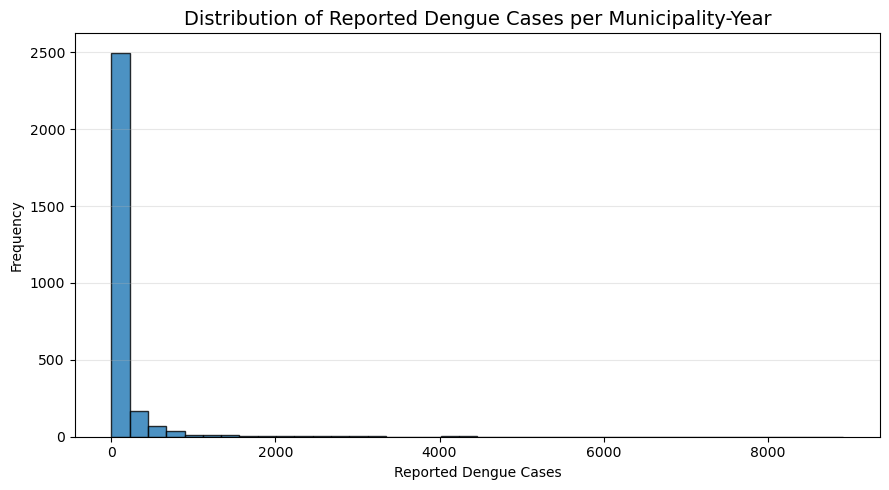

In [12]:
plt.figure(figsize=(9, 5))

plt.hist(
    year_municipality["total_cases"],
    bins=40,
    edgecolor='black',
    alpha=0.8
)

plt.title("Distribution of Reported Dengue Cases per Municipality-Year", fontsize=14)
plt.xlabel("Reported Dengue Cases")
plt.ylabel("Frequency")

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Dengue case counts are highly concentrated at low values, while a relatively small number of municipality-year observations contribute to large outbreaks, producing a strongly right-skewed distribution.


**Boxplot**


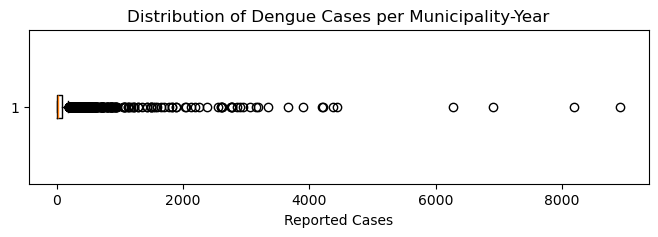

In [13]:
plt.figure(figsize=(8, 2))

plt.boxplot(year_municipality["total_cases"], vert=False)

plt.title("Distribution of Dengue Cases per Municipality-Year")
plt.xlabel("Reported Cases")

plt.show()

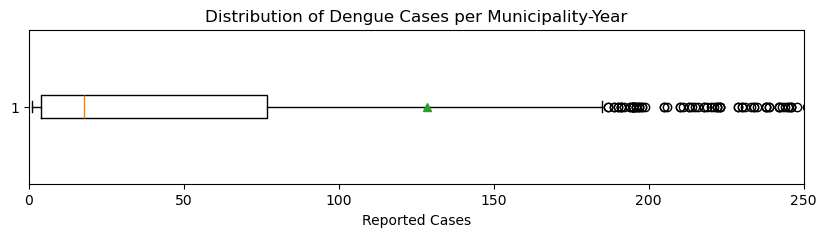

In [14]:
plt.figure(figsize=(10, 2))

plt.boxplot(year_municipality["total_cases"], vert=False, showmeans=True)

plt.xlim(0, 250)   # Zoom in
plt.title("Distribution of Dengue Cases per Municipality-Year")
plt.xlabel("Reported Cases")

plt.show()

**Potential outliers**

The boxplot reinforces the findings from the histogram and descriptive statistics. The distribution of dengue cases per municipality-year is strongly right-skewed, with the middle 50% of observations ranging from 4 to 78 reported cases. The large number of observations beyond the upper fence (189 cases) indicates that unusually large outbreaks occurred across multiple municipality-years. These observations should be investigated further, as they may represent true epidemic events rather than data errors.


### 3.3 Concentration of Dengue Burden

**Pareto Analysis**


In [15]:
pareto_df = (
    municipality
    .sort_values(by="total_cases", ascending=False)
    .reset_index(drop=True)
)
pareto_df["cumulative_cases"] = pareto_df["total_cases"].cumsum()
total_cases = pareto_df["total_cases"].sum()
pareto_df["cumulative_%"] = (pareto_df["cumulative_cases"] / total_cases) * 100
pareto_df.head(10)


,municipality,department,total_cases,cumulative_cases,cumulative_%
0,COATEPEQUE,QUETZALTENANGO,22599,22599,6.196940
1,GUATEMALA,GUATEMALA,20709,43308,11.875617
2,MIXCO,GUATEMALA,16607,59915,16.429472
3,JUTIAPA,JUTIAPA,15519,75434,20.684984
4,ANTIGUA GUATEMALA,SACATEPEQUEZ,11088,86522,23.725458
5,ESCUINTLA,ESCUINTLA,9488,96010,26.327191
6,ZACAPA,ZACAPA,8034,104044,28.530218
7,AMATITLÁN,GUATEMALA,7768,111812,30.660305
8,POPTÚN,EL PETEN,7064,118876,32.597346
9,SALAMÁ,BAJA VERAPAZ,7009,125885,34.519305


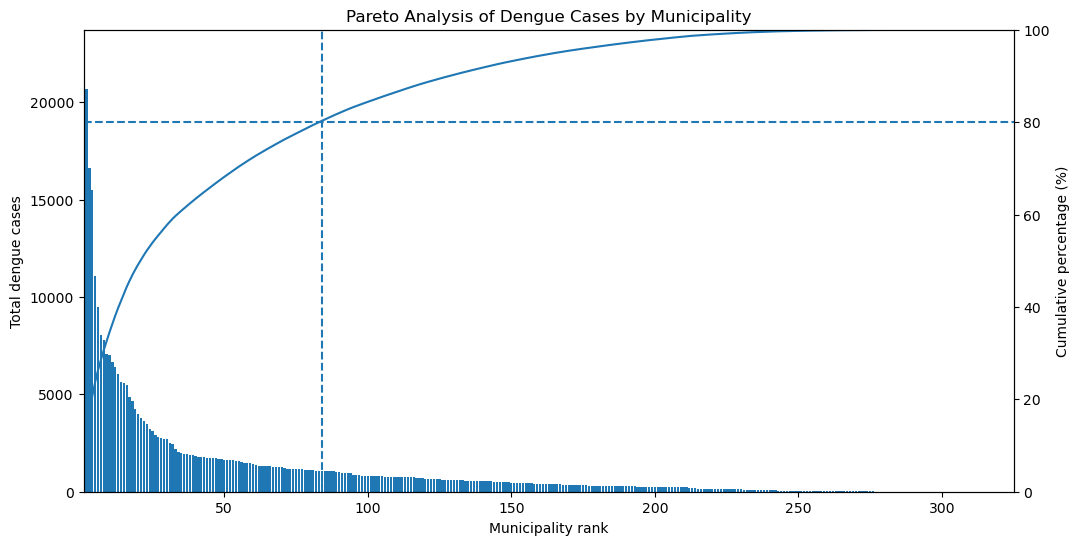

In [16]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(
    x=range(1, len(pareto_df) + 1),
    height=pareto_df["total_cases"]
)
ax1.set_xlabel("Municipality rank")
ax1.set_ylabel("Total dengue cases")
ax1.set_title(
    "Pareto Analysis of Dengue Cases by Municipality"
)
ax1.set_xlim(1, len(pareto_df))

ax2 = ax1.twinx()
ax2.plot(
    range(1, len(pareto_df) + 1),
    pareto_df["cumulative_%"]
)
ax2.set_ylabel("Cumulative percentage (%)")
ax2.set_ylim(0, 100)

ax2.axhline(
    y=80,
    linestyle="--"
)

threshold_row = pareto_df[
    pareto_df["cumulative_%"] >= 80
].iloc[0]

threshold_rank = threshold_row.name + 1

ax1.axvline(
    x=threshold_rank,
    linestyle="--"
)

In [17]:
municipality_percentage = (threshold_rank / len(pareto_df)) * 100
print(f"Approximately {municipality_percentage:.2f}% of municipalities account for 80% of the total dengue cases.")

Approximately 25.85% of municipalities account for 80% of the total dengue cases.


**Interpretation**

The Pareto analysis summarizes how cumulative dengue burden is distributed across municipalities and identifies the share of municipalities accounting for 80% of reported dengue cases.


## 4. Temporal Analysis


### 4.1 Annual Dengue Cases

How has the burden of dengue changed over time in Guatemala from 2012 to 2024?


### 4.2 Year-over-Year Change


In [18]:
year_totals["case difference"] = year_totals["total_cases"].diff()
year_totals["percent_change"] = year_totals["total_cases"].pct_change() * 100

In [19]:
year_totals

,year,total_cases,case difference,percent_change
0,2012,10296,NaN,NaN
1,2013,12833,2537.0,24.640637
2,2014,19735,6902.0,53.783215
3,2015,18612,-1123.0,-5.690398
4,2016,9016,-9596.0,-51.558135
5,2017,4213,-4803.0,-53.271961
6,2018,7523,3310.0,78.566342
7,2019,50597,43074.0,572.564137
8,2020,6011,-44586.0,-88.119849
9,2021,2918,-3093.0,-51.455665


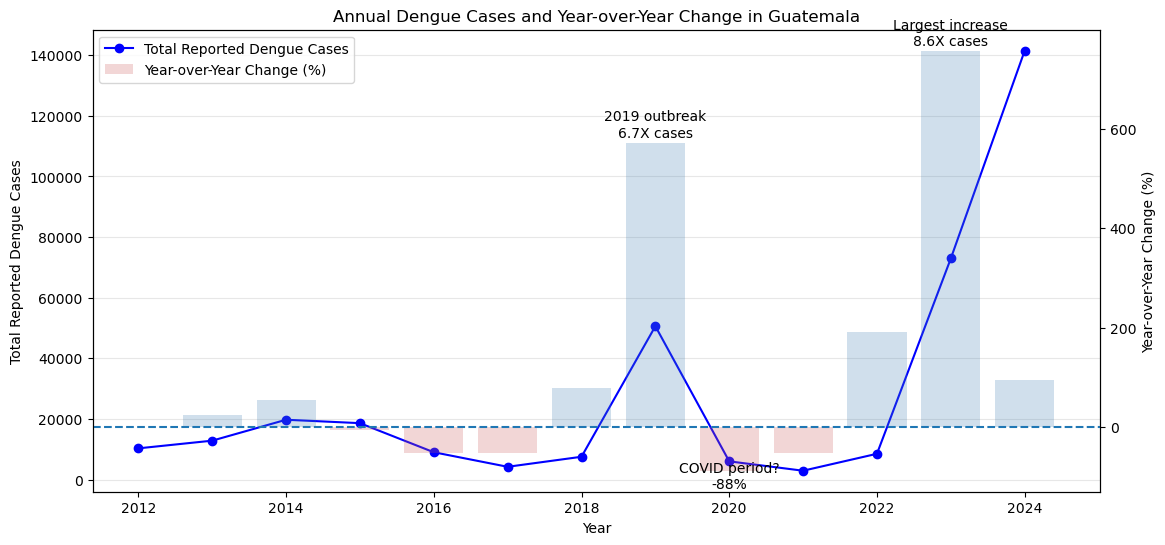

In [20]:
fig, ax1 = plt.subplots(figsize=(13, 6))

ax1.plot(
    year_totals["year"],
    year_totals["total_cases"],
    marker='o',
    label="Total Reported Dengue Cases",
    color='blue'
)

ax1.set_xlabel("Year")
ax1.set_ylabel("Total Reported Dengue Cases")
ax1.set_title("Annual Dengue Cases and Year-over-Year Change in Guatemala")

ax1.grid(
    axis="y",
    alpha=0.3
)

bar_colors = [
    "steelblue" if value >= 0 else "indianred"
    for value in year_totals["percent_change"]
]

ax2 = ax1.twinx()

ax2.bar(
    year_totals["year"],
    year_totals["percent_change"],
    color=bar_colors,
    alpha=0.25,
    label="Year-over-Year Change (%)",
)

ax2.set_ylabel("Year-over-Year Change (%)")
ax2.axhline(
    y=0,
    linestyle="--",
)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper left"
)

annotations = {
    2019: "2019 outbreak\n6.7X cases",
    2020: "COVID period?\n-88%",
    2023: "Largest increase\n8.6X cases"
}

for year, label in annotations.items():

    year_data = year_totals[
        year_totals["year"] == year
    ].iloc[0]

    x_coordinate = year_data["year"]
    y_coordinate = year_data["percent_change"]

    if year == 2020:
        offset = (0, -13)
    else:
        offset = (0, 4)

    ax2.annotate(
        label,
        xy=(x_coordinate, y_coordinate),
        xytext=offset,
        textcoords="offset points",
        ha="center"
    )


### 4.3 Interpretation

Reported dengue cases remained relatively moderate from 2012 through 2018, despite year-to-year fluctuations. In 2019, Guatemala experienced a major outbreak, with reported cases increasing to approximately 6.7 times compared with the previous year. This was followed by a steep decline in 2020. After a short recovery period, another major outbreak occurred in 2023, producing the largest year-over-year percentage increase (8.6 times the previous year's reported cases). Reported cases then reached their highest absolute total in 2024. These major fluctuations may reflect underlying epidemiological dynamics, changes in surveillance or reporting, or other contextual factors not captured in the available data. Further investigation using additional epidemiological and contextual data would therefore be necessary to explain these patterns.


## 5. Municipality-Level Spatial Analysis


### 5.1 Municipalities with the Highest Cumulative Burden

Which municipalities contributed the greatest dengue burden?


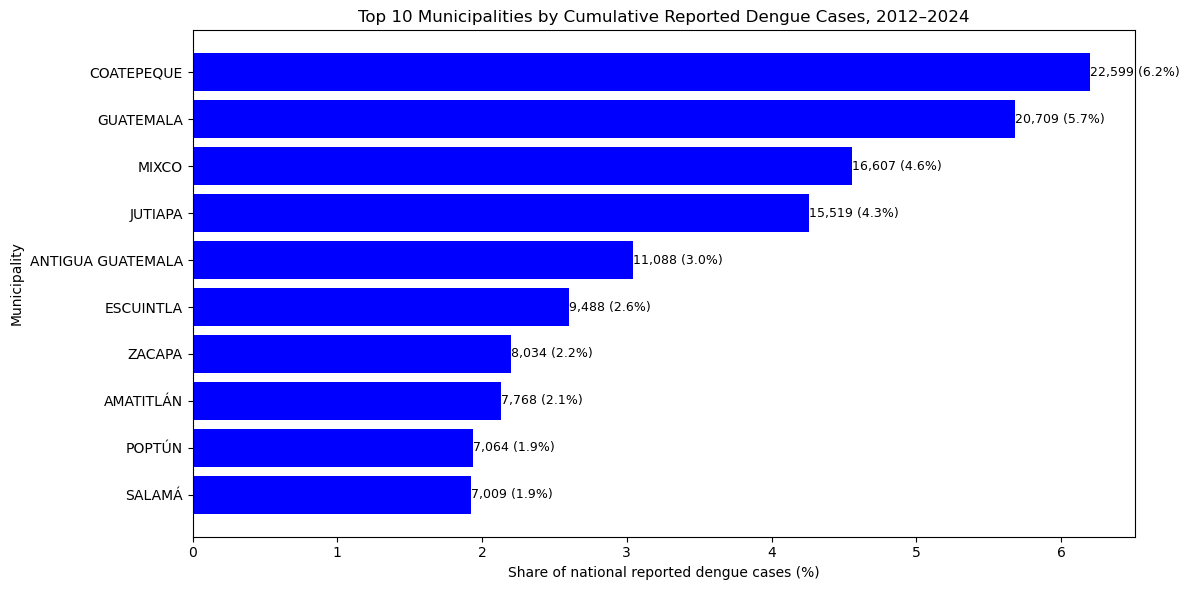

In [21]:
municipality_top_10 = municipality.sort_values(by="total_cases", ascending=False).head(10)
municipality_top_10["percentage_of_cases"] = (
    municipality_top_10["total_cases"] / municipality["total_cases"].sum()
) * 100

plt.figure(figsize=(12, 6))
bars = plt.barh(
    municipality_top_10["municipality"],
    municipality_top_10["percentage_of_cases"],
    color="blue"
)

for bar, cases, pct in zip(
    bars,
    municipality_top_10["total_cases"],
    municipality_top_10["percentage_of_cases"]
):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f"{cases:,} ({pct:.1f}%)",
        va="center",
        ha="left",
        fontsize=9
    )

plt.gca().invert_yaxis()
plt.xlabel("Share of national reported dengue cases (%)")
plt.ylabel("Municipality")
plt.title("Top 10 Municipalities by Cumulative Reported Dengue Cases, 2012–2024")
plt.tight_layout()
plt.show()


There does not seem to be one single municipality that overwhelmingly contributes to the national cumulative dengue burden. It is possible that dengue burden is geographically concentrated at the department level, and that will be explored next.


### 5.2 Share of National Reported Cases


In [22]:
percentage_share_top_10 = municipality_top_10["percentage_of_cases"].sum()
print(f"The top 10 municipalities account for approximately {percentage_share_top_10:.2f}% of the total reported dengue cases in Guatemala from 2012 to 2024.")

The top 10 municipalities account for approximately 34.52% of the total reported dengue cases in Guatemala from 2012 to 2024.


The ten municipalities with the highest cumulative dengue burden accounted for approximately 34.5% of all reported dengue cases in Guatemala between 2012 and 2024. Although no individual municipality contributed more than 6.2% of the national total, a small group of municipalities accounted for more than one-third of all reported cases. This suggests that dengue burden is geographically concentrated rather than evenly distributed across municipalities.


### 5.3 Persistence in the Annual Top 10


In [23]:
municipalities_grouped_year = year_municipality.groupby('year')
top10_each_year = municipalities_grouped_year.apply(
    lambda group: group.sort_values('total_cases', ascending=False).head(10)
)
top10_each_year = top10_each_year.reset_index(drop=False)
top10_each_year = top10_each_year.drop(columns="level_1")

top10_frequency = (
    top10_each_year[["municipality", "department"]]
    .value_counts()
    .reset_index(name="years_in_top_10")
)

top10_frequency


,municipality,department,years_in_top_10
0,COATEPEQUE,QUETZALTENANGO,12
1,GUATEMALA,GUATEMALA,10
2,ZACAPA,ZACAPA,9
3,JUTIAPA,JUTIAPA,7
4,PUERTO BARRIOS,IZABAL,7
5,ANTIGUA GUATEMALA,SACATEPEQUEZ,7
6,ESCUINTLA,ESCUINTLA,6
7,MIXCO,GUATEMALA,6
8,SALAMÁ,BAJA VERAPAZ,5
9,AMATITLÁN,GUATEMALA,4


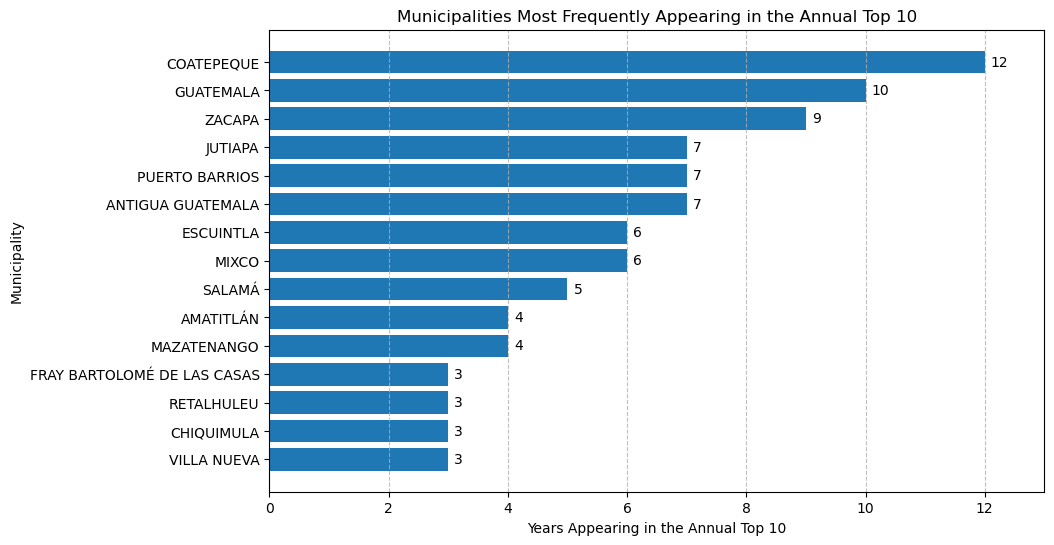

In [24]:
top15 = top10_frequency.head(15)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    top15["municipality"],
    top15["years_in_top_10"]
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width)}",
        va="center",
        ha="left"
    )

ax.set_xlabel("Years Appearing in the Annual Top 10")
ax.set_ylabel("Municipality")
ax.set_title("Municipalities Most Frequently Appearing in the Annual Top 10")

ax.grid(
    axis="x",
    linestyle="--",
    linewidth=0.8,
    alpha=0.8
)
ax.set_xlim(0, 13)

ax.invert_yaxis()

### 5.4 Interpretation

Although only 47 of the 325 municipalities (14%) appeared in the annual Top 10 at least once during the study period, these municipalities included several persistent high-burden locations. Coatepeque appeared in the annual Top 10 during 12 of the 13 years analyzed, followed by Guatemala (10 years) and Zacapa (9 years). Together with the finding that the Top 10 municipalities accounted for 34.5% of all reported dengue cases, these results suggest that dengue burden was geographically concentrated in a relatively small subset of municipalities rather than being evenly distributed across Guatemala.


## 6. Department-Level Spatial Analysis


### 6.1 Cumulative Dengue Burden by Department

Is dengue burden even more geographically concentrated when municipalities are aggregated into departments?


In [25]:
municipality_aggregate = (
    municipality
    .groupby('department')
    .agg(total_cases=('total_cases', 'sum'))
    .sort_values(by='total_cases', ascending=False)
    .reset_index()
)

national_cases = municipality_aggregate['total_cases'].sum()

municipality_aggregate["percentage_of_cases"] = (
    municipality_aggregate["total_cases"] / national_cases
) * 100


### 6.2 Share of National Reported Cases


Text(0.5, 1.0, 'Share of National Reported Dengue Cases by Department, 2012–2024')

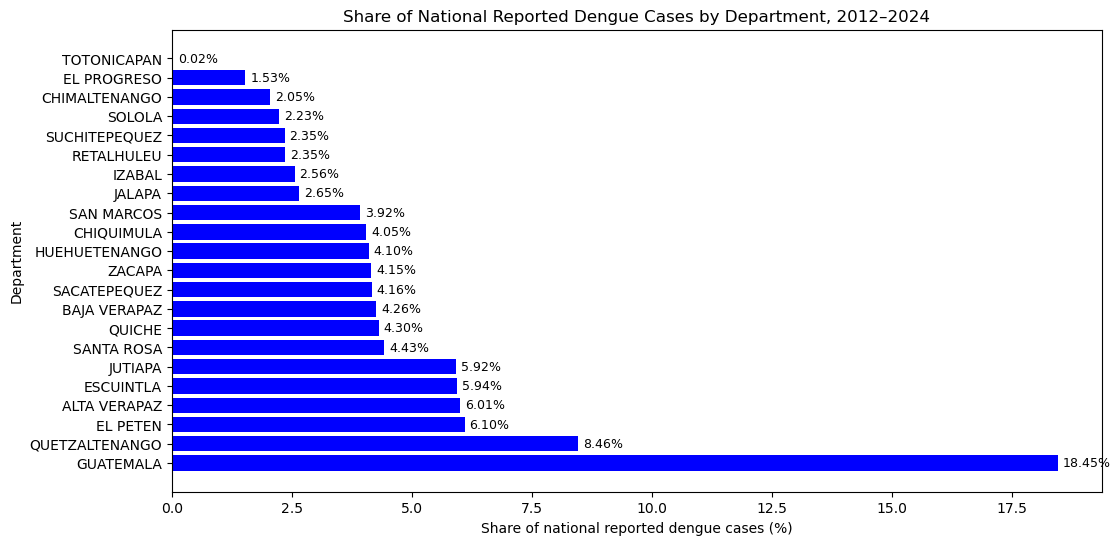

In [26]:
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(
    municipality_aggregate["department"],
    municipality_aggregate["percentage_of_cases"],
    color="blue"
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}%",
        va="center",
        ha="left",
        fontsize=9
    )

ax.set_xlabel("Share of national reported dengue cases (%)")
ax.set_ylabel("Department")
ax.set_title("Share of National Reported Dengue Cases by Department, 2012–2024")


### 6.3 Interpretation

The distribution of reported dengue cases across departments is not uniform. Guatemala Department accounts for nearly one-fifth of all reported cases during the study period, making it the dominant contributor. Quetzaltenango forms a second tier with approximately 8.5% of national cases, while most remaining departments contribute between 2% and 6%, suggesting a moderate level of geographic concentration rather than an even distribution across the country.


### 6.4 Department patterns over time: Were the same departments consistently responsible for the largest shares of reported dengue cases, or did the geographic distribution change over time?


In [27]:
year_cumulative_department = (
    year_municipality
    .groupby(["year", "department"])
    .agg(total_cases=("total_cases", "sum"))
    .reset_index()
)

In [28]:
year_cumulative_department.shape
year_cumulative_department.groupby("year")["department"].nunique()

year
2012    21
2013    22
2014    22
2015    22
2016    22
2017    22
2018    21
2019    22
2020    22
2021    22
2022    22
2023    22
2024    22
Name: department, dtype: int64

In [29]:
year_cumulative_department = year_cumulative_department.rename(
    columns={"total_cases": "department_cases"}
)

year_totals = year_totals.rename(
    columns={"total_cases": "national_cases"}
)

In [30]:
department_year_share = year_cumulative_department.merge(
    year_totals,
    on="year",
    how="left"  
)

# Calculate the percentage of each department's cases relative to the national total for that year
department_year_share["percentage_national_cases"] = (
    department_year_share["department_cases"]
    / department_year_share["national_cases"]
    * 100
)

# Group the department by year and save it in a new variable 
department_grouped_year = department_year_share.groupby('year')

# Get the top 5 departments for each year based on the percentage of national cases
top5_departments_year = department_grouped_year.apply(
    lambda group: group.sort_values('percentage_national_cases', ascending=False).head(5)
)

top5_departments_year.loc[[2019, 2023, 2024]]

department  department_cases  national_cases  case difference  \
year                                                                          
2019 156        EL PETEN              7350           50597          43074.0   
     160   HUEHUETENANGO              6172           50597          43074.0   
     159       GUATEMALA              6002           50597          43074.0   
     164  QUETZALTENANGO              3782           50597          43074.0   
     152    ALTA VERAPAZ              3398           50597          43074.0   
2023 247       GUATEMALA             14704           72943          64438.0   
     253          QUICHE              6488           72943          64438.0   
     252  QUETZALTENANGO              5590           72943          64438.0   
     246       ESCUINTLA              4950           72943          64438.0   
     243      CHIQUIMULA              4774           72943          64438.0   
2024 269       GUATEMALA             25075          141478          68535.0   
     273         JUTIAPA             12602          141478          68535.0   
     262    ALTA VERAPAZ             10758          141478          68535.0   
     274  QUETZALTENANGO             10515          141478          68535.0   
     278      SAN MARCOS              7582          141478          68535.0   

          percent_change  percentage_national_cases  
year                                                 
2019 156      572.564137                  14.526553  
     160      572.564137                  12.198352  
     159      572.564137                  11.862363  
     164      572.564137                   7.474751  
     152      572.564137                   6.715813  
2023 247      757.648442                  20.158206  
     253      757.648442                   8.894616  
     252      757.648442                   7.663518  
     246      757.648442                   6.786121  
     243      757.648442                   6.544836  
2024 269       93.956925                  17.723604  
     273       93.956925                   8.907392  
     262       93.956925                   7.604009  
     274       93.956925                   7.432251  
     278       93.956925                   5.359137

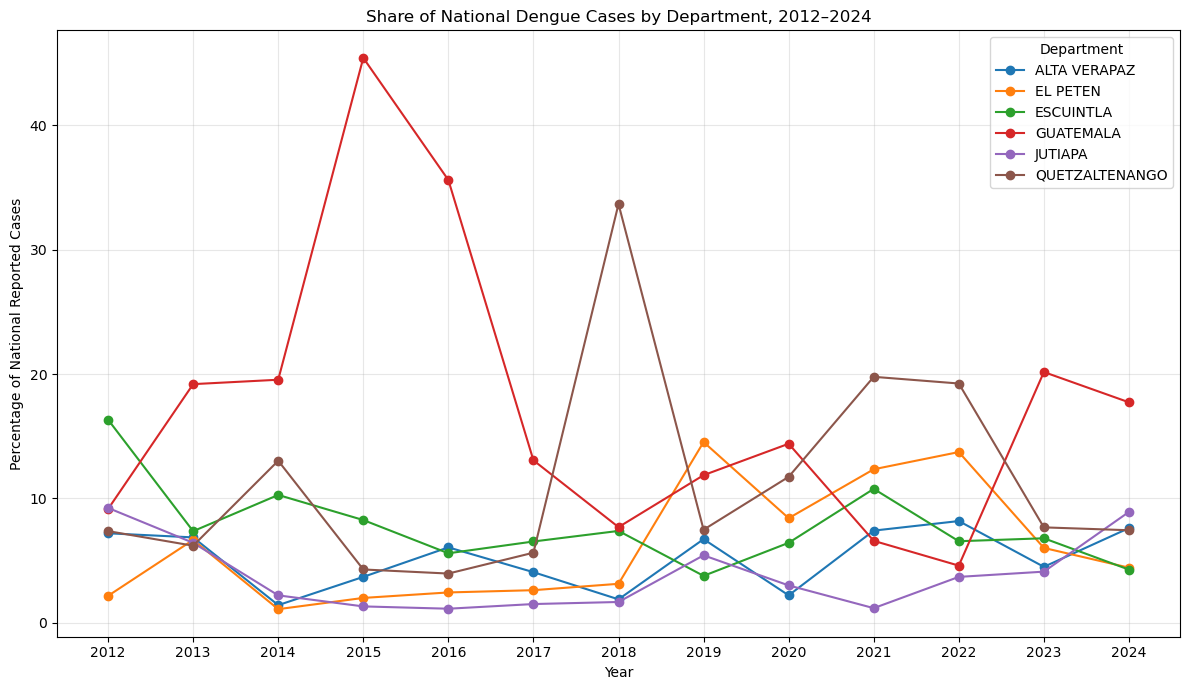

In [31]:
# Plot the top 6 departments by cumulative cases
top6_departments = municipality_aggregate["department"].head(6)

top6_department_trends = department_year_share[
    department_year_share["department"].isin(top6_departments)
]

plt.figure(figsize=(12, 7))

for department, group in top6_department_trends.groupby("department"):
    plt.plot(
        group["year"],
        group["percentage_national_cases"],
        marker="o",
        label=department
    )

plt.xlabel("Year")
plt.ylabel("Percentage of National Reported Cases")
plt.title("Share of National Dengue Cases by Department, 2012–2024")

plt.xticks(range(2012, 2025))
plt.legend(title="Department")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Inspect mean and standard deviation of the percentage of national cases for each department for consistency
department_consistency = top6_department_trends.groupby("department").agg(
    mean_percentage=("percentage_national_cases", "mean"),
    std_dev_percentage=("percentage_national_cases", "std")
).reset_index()

# Calculate coefficient of variation (CV) for each department
department_consistency["cv_percentage"] = (
    department_consistency["std_dev_percentage"]
    / department_consistency["mean_percentage"]
    * 100
)

,department,mean_percentage,std_dev_percentage,cv_percentage
0,ALTA VERAPAZ,5.207762,2.376312,45.630193
1,EL PETEN,6.112563,4.730657,77.392363
2,ESCUINTLA,7.710459,3.264617,42.340107
3,GUATEMALA,17.302470,11.671932,67.458184
4,JUTIAPA,3.822241,2.866061,74.983789
5,QUETZALTENANGO,11.338558,8.457578,74.591299



The six departments with the highest cumulative dengue burden did not contribute consistently to the national total across years. Guatemala exhibited the greatest absolute variability in annual national case share (SD = 11.67 percentage points), while Petén showed the greatest variability relative to its mean contribution (CV = 77.4%). Escuintla and Alta Verapaz had the lowest relative variability among the six departments, with CVs of 42.3% and 45.6%, respectively.

Guatemala Department was the largest contributor on average among the six highest-burden departments, with a mean annual share of 17.3% of national reported cases. However, its annual contribution was highly variable (SD = 11.67 percentage points; CV = 67.46%), indicating that its relative contribution to the national dengue burden changed substantially across years.

## 6.5 Pareto Distribution

In [47]:
# Aggregate percentage of cases by department to identify which departments contribute most to the national total
municipality_aggregate["cumulative_percentage"] = (
    municipality_aggregate["percentage_of_cases"]
    .cumsum()
)

threshold_row = municipality_aggregate[municipality_aggregate["cumulative_percentage"] >= 80].iloc[0]
total_departments = len(municipality_aggregate)
departments_to_80 = threshold_row.name + 1

percentage_departments_to_80 = departments_to_80/total_departments * 100
percentage_departments_to_80

59.09090909090909

The 13 highest-burden departments, representing approximately 59.1% of Guatemala’s 22 departments, accounted for 80.34% of reported dengue cases during 2012–2024.

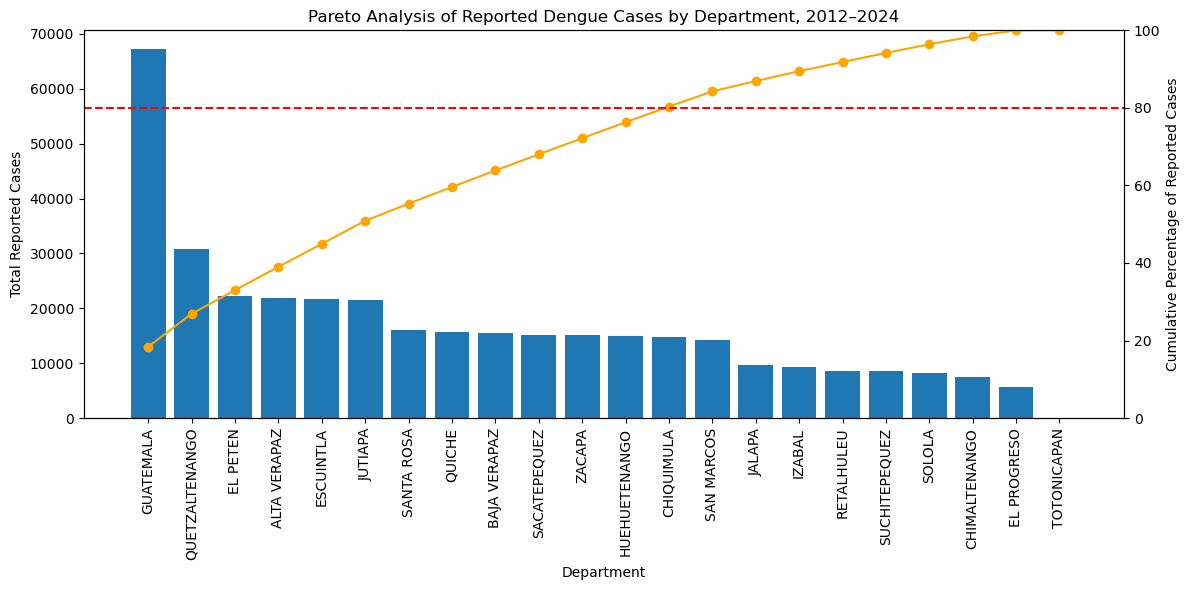

In [63]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(
    municipality_aggregate["department"],
    municipality_aggregate["total_cases"]
)

ax1.set_ylabel("Total Reported Cases")
ax1.tick_params(axis="x", rotation=90)
ax1.set_xlabel("Department")
ax1.set_title("Pareto Analysis of Reported Dengue Cases by Department, 2012–2024")

ax2 = ax1.twinx()
ax2.plot(
    municipality_aggregate["department"],
    municipality_aggregate["cumulative_percentage"],
    color="orange",
    marker="o"
)

ax2.set_ylabel("Cumulative Percentage of Reported Cases")
ax2.set_ylim(0, 100)

ax2.axhline(
    y=80,
    color="red",
    linestyle="--"
)

plt.tight_layout()
plt.show()

Thirteen of the 22 departments (59.1%) accounted for 80.34% of reported dengue cases, which does not resemble a strong 80/20 concentration at the department level. Geographic concentration was more pronounced at the municipality level, where approximately 25% of municipalities accounted for 80% of reported cases. This suggests that the dengue burden was concentrated more strongly within particular municipalities than across departments as a whole.

## 7. Preliminary Conclusions
Reported dengue cases in Guatemala followed a highly variable temporal pattern between 2012 and 2024 rather than a steady increase. The series was characterized by substantial year-to-year fluctuations, including major increases in 2019 and 2023, followed by the highest reported case total in the study period in 2024.

Reported dengue cases were geographically concentrated, but the degree of concentration depended on the level of aggregation. At the municipality level, approximately 25% of municipalities accounted for 80% of reported cases, indicating substantial local concentration. In contrast, 13 of 22 departments (59.1%) were required to account for 80.34% of cases, suggesting that geographic concentration was more pronounced at the municipality level.

The geographic distribution of reported dengue cases also showed both persistence and temporal variation. Some municipalities repeatedly appeared among the highest-burden locations across multiple years, indicating persistent geographic concentrations. However, department-level national case shares varied substantially over time, showing that the relative contribution of different geographic areas was not constant throughout the study period.

Overall, the analysis indicates that Guatemala’s reported dengue burden during 2012–2024 was characterized by substantial temporal variability, geographic concentration, and changing spatial patterns. These findings describe reported case burden rather than dengue incidence or individual risk, since population denominators were not incorporated into the analysis.


## 8. Limitations and Future Work

This analysis has several limitations that should be considered when interpreting the results. First, the analysis is based on reported case counts and does not account for differences in population size across municipalities or departments. Therefore, the geographic patterns identified represent differences in reported dengue burden rather than incidence or individual risk.

Second, not all geographic-year combinations were present in the dataset. In particular, no municipality-level records were available for Totonicapán in 2012 and 2018. These absent records were not assumed to represent zero cases because the available data do not establish whether they reflect a true absence of reported cases or missing reporting.

Third, the dataset represents reported surveillance cases and may not capture all dengue infections that occurred during the study period. Differences in diagnosis, healthcare access, case detection, and reporting could influence the observed counts.

Finally, this project is descriptive and does not include explanatory variables that could account for the temporal and geographic patterns observed. Consequently, the analysis identifies when and where reported dengue burden was concentrated but does not establish the causes of these patterns.

Future work could incorporate annual population estimates to calculate incidence rates, such as reported cases per 100,000 inhabitants, allowing geographic areas to be compared relative to population size. Additional work could investigate incomplete geographic-year records and integrate demographic, environmental, climatic, or other relevant variables to explore factors associated with the observed dengue patterns.